<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-1/blob/main/Question_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Question 02**

This section addresses Question 02, which involves processing the `highlights_and_shadows.jpg` image.

#### (a) Apply gamma correction to the L plane in the L*a*b* color space and state the $\gamma$ value.

In [2]:
from google.colab import files

print("Please select 'highlights_and_shadows.jpg' to upload.")
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')

# Optionally, you can move the file if it's not directly in /content
# import os
# for filename in uploaded.keys():
#   if not os.path.exists(f'/content/{filename}'):
#     os.rename(filename, f'/content/{filename}')

Please select 'highlights_and_shadows.jpg' to upload.


Saving highlights_and_shadows.jpg to highlights_and_shadows (1).jpg
User uploaded file "highlights_and_shadows (1).jpg" with length 66738 bytes


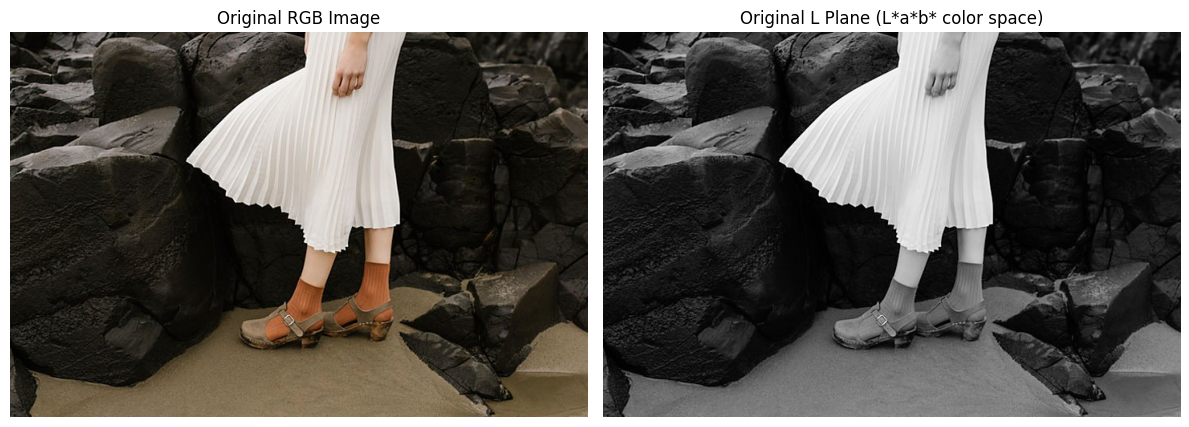

In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from skimage import color

# Load the image
image_path_q2 = '/content/highlights_and_shadows.jpg'
original_image_rgb = Image.open(image_path_q2).convert('RGB')
original_image_np_rgb = np.array(original_image_rgb) / 255.0 # Normalize to [0, 1]

# Convert RGB to L*a*b*
image_lab = color.rgb2lab(original_image_np_rgb)

# Extract the L plane (lightness)
l_plane = image_lab[:, :, 0]

# Display the original RGB image and the extracted L plane
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_image_np_rgb)
axes[0].set_title('Original RGB Image')
axes[0].axis('off')

axes[1].imshow(l_plane, cmap='gray')
axes[1].set_title('Original L Plane (L*a*b* color space)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Applying gamma correction with a $\gamma$ value of **0.5** to the L plane will make the image brighter, enhancing details in the darker areas. This value is chosen to likely improve visibility in shadowed regions of the `highlights_and_shadows.jpg` image.

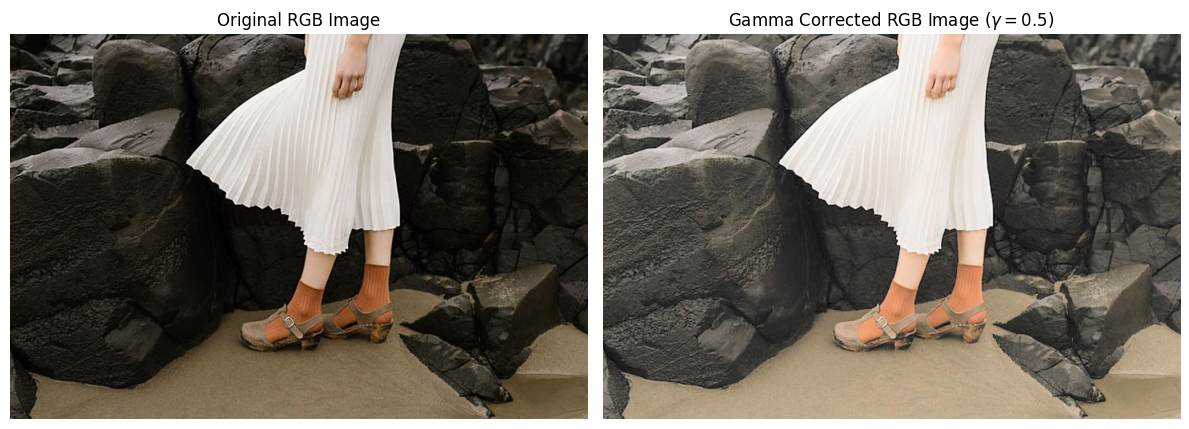

In [4]:
# Define the gamma value
gamma_value = 0.5

# Apply gamma correction to the L plane
# First, normalize L plane to [0, 1] if not already (skimage rgb2lab outputs L in [0, 100])
l_plane_normalized = l_plane / 100.0
gamma_corrected_l_plane_normalized = np.power(l_plane_normalized, gamma_value)

# Scale back to [0, 100] for L*a*b* color space
gamma_corrected_l_plane = gamma_corrected_l_plane_normalized * 100.0

# Recombine the corrected L plane with the original a and b planes
corrected_image_lab = np.copy(image_lab)
corrected_image_lab[:, :, 0] = gamma_corrected_l_plane

# Convert back to RGB for display
corrected_image_rgb = color.lab2rgb(corrected_image_lab)

# Display the original and gamma-corrected images
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(original_image_np_rgb)
axes[0].set_title('Original RGB Image')
axes[0].axis('off')

axes[1].imshow(corrected_image_rgb)
axes[1].set_title(r'Gamma Corrected RGB Image ($\gamma={}$)' .format(gamma_value))
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### (b) Show the histograms of the original and corrected images.

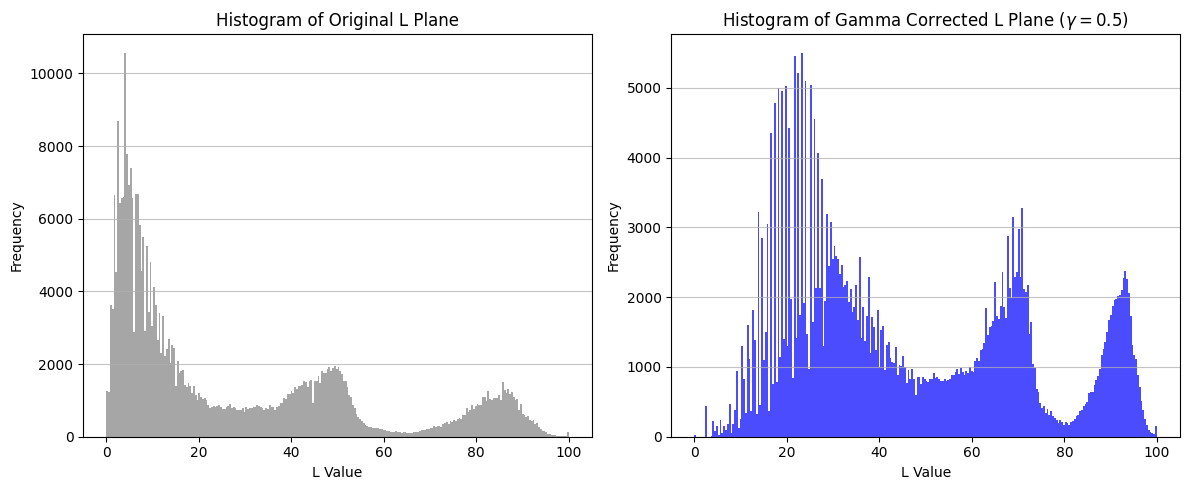

In [5]:
# Plot histograms of the original and gamma-corrected L planes
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(l_plane.flatten(), bins=256, range=(0, 100), color='gray', alpha=0.7)
plt.title('Histogram of Original L Plane')
plt.xlabel('L Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.subplot(1, 2, 2)
plt.hist(gamma_corrected_l_plane.flatten(), bins=256, range=(0, 100), color='blue', alpha=0.7)
plt.title(r'Histogram of Gamma Corrected L Plane ($\gamma={}$)' .format(gamma_value))
plt.xlabel('L Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()